# 10 — Visualization

**The concept:** an XDSM-style diagram of the pipeline, rendered with pure matplotlib. Same purpose
as `explain()` — showing someone the structure — for the cases where a picture carries it better
than a paragraph.

In [1]:
import matplotlib
matplotlib.use("Agg", force=True)     # required in any headless process

import pathlib
from smartmdao import Pipeline, HybridSolver

output_dir = pathlib.Path("_diagrams")
output_dir.mkdir(exist_ok=True)

aircraft = Pipeline(solver=HybridSolver())

@aircraft.step(outputs=["lift"])
def aerodynamics(span: float, speed: float, mass: float) -> float:
    return 0.5 * 1.225 * speed**2 * span * 1.2

@aircraft.step(outputs=["mass"])
def structures(span: float, lift: float) -> float:
    return 200.0 + 0.5 * span + 0.001 * lift

@aircraft.step(outputs=["range_km"])
def performance(lift: float, mass: float) -> float:
    return 100.0 * lift / mass

print("steps:", [s.name for s in aircraft.steps])

steps: ['aerodynamics', 'structures', 'performance']


## `pipeline.visualize()`

**Always pass `view=False` outside a notebook with a display.** The default is `view=True`, which
calls `plt.show()` and blocks forever with no display attached — the sharpest edge in this part of
the library, and the library deliberately does not force a backend on you because that would change
behaviour for interactive users.

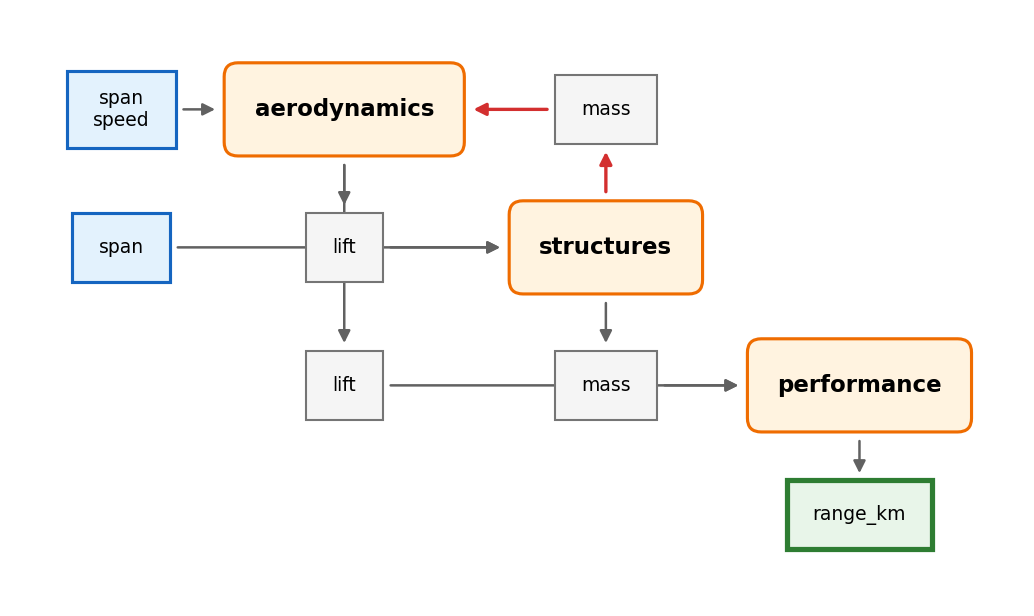

In [2]:
diagram = output_dir / "aircraft.png"

aircraft.visualize(
    inputs=["span", "speed"],
    output_path=str(diagram),
    view=False,
)

from IPython.display import Image
Image(filename=str(diagram))

Read it the way an XDSM is read: **diagonal blocks are disciplines**, off-diagonal entries are
the variables passed between them. Anything flowing back up and to the left is a **feedback** edge —
which is what makes this problem cyclic, and what `HybridSolver` will iterate.

The diagonal order is not registration order. It is computed from the graph, so it matches what the
solver will actually do.

In [3]:
from smartmdao import analyze

print("diagram diagonal follows:", analyze(aircraft, inputs=["span", "speed"]).execution_order)

diagram diagonal follows: ('aerodynamics', 'structures', 'performance')


## `orientation` and `graph_type` are inert

Both parameters are still in the signature and still accepted, but **neither changes the output**.
They are kept for backward compatibility: the XDSM view already combines what `"flow"` and
`"bipartite"` used to show separately, and an XDSM always reads top-left to bottom-right, so there
is no `"LR"` variant to render.

This is worth demonstrating rather than asserting, because the signature's `Literal["flow",
"bipartite"]` type reasonably suggests otherwise.

In [4]:
import hashlib

variants = {
    "flow / TB":      dict(graph_type="flow", orientation="TB"),
    "bipartite / LR": dict(graph_type="bipartite", orientation="LR"),
    "flow / LR":      dict(graph_type="flow", orientation="LR"),
}

digests = {}
for label, kwargs in variants.items():
    path = output_dir / (label.replace(" ", "").replace("/", "_") + ".png")
    aircraft.visualize(inputs=["span", "speed"], output_path=str(path), view=False, **kwargs)
    digests[label] = hashlib.sha256(path.read_bytes()).hexdigest()[:16]

for label, digest in digests.items():
    print(f"{label:16} sha256 {digest}")

print()
print("identical:", len(set(digests.values())) == 1)

flow / TB        sha256 584ad57a769c0d9f
bipartite / LR   sha256 584ad57a769c0d9f
flow / LR        sha256 584ad57a769c0d9f

identical: True


Byte-identical. If you are choosing between them expecting different pictures, you are not —
pass neither and read the XDSM.

## Output format follows the extension

`.png` gives a raster; `.pdf` and `.svg` give vectors, which are what you want for a document.
Without an extension it defaults to PDF.

In [5]:
for suffix in (".png", ".svg", ".pdf"):
    path = output_dir / f"aircraft{suffix}"
    aircraft.visualize(inputs=["span", "speed"], output_path=str(path), view=False)
    print(f"{suffix:5} -> {path.stat().st_size:7,} bytes")

.png  ->  31,268 bytes


.svg  ->  28,101 bytes


.pdf  ->  15,424 bytes


## Rendering a cyclic pipeline versus an acyclic one

The feedback edge is the thing to look for. Here is the same model with the loop removed, so you can
see what the difference looks like on the page.

cyclic model  has cycles: True
acyclic model has cycles: False


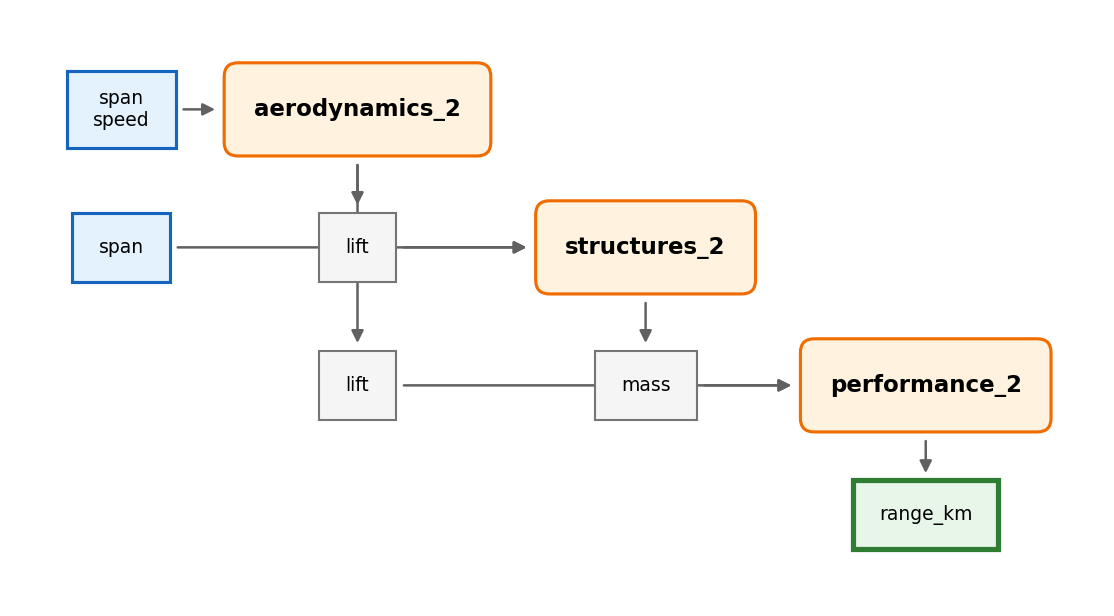

In [6]:
acyclic = Pipeline()

@acyclic.step(outputs=["lift"])
def aerodynamics_2(span: float, speed: float) -> float:      # no `mass` input, so no loop
    return 0.5 * 1.225 * speed**2 * span * 1.2

@acyclic.step(outputs=["mass"])
def structures_2(span: float, lift: float) -> float:
    return 200.0 + 0.5 * span + 0.001 * lift

@acyclic.step(outputs=["range_km"])
def performance_2(lift: float, mass: float) -> float:
    return 100.0 * lift / mass

print("cyclic model  has cycles:", analyze(aircraft, inputs=["span", "speed"]).has_cycles)
print("acyclic model has cycles:", analyze(acyclic, inputs=["span", "speed"]).has_cycles)

straight = output_dir / "acyclic.png"
acyclic.visualize(inputs=["span", "speed"], output_path=str(straight), view=False)
Image(filename=str(straight))

## In a headless process

Inside a script, a CI job or a server, two things every time:

```python
matplotlib.use("Agg", force=True)
pipeline.visualize(..., view=False)
```

The MCP rendering path already does both, so diagrams requested through the connector are safe. A
direct call is not.

---

**Next:** [11 — Discretisation](11-discretisation.ipynb).

In [7]:
import shutil
shutil.rmtree(output_dir)     # leave nothing behind
print("cleaned up")

cleaned up
